# "Manually" working with streetscapes databases

The streetscapes CLI is an easy way to download and segment street view images.
These can all be viewed in the explorer as well.

However, for some more specific use-cases it can be necessary to work with the project database directly.
For this we have created some utilities to make it easier.

## Database access

Let's start by importing the required functions from the streetscapes package:


In [1]:
from streetscapes.utils.db_access import get_image, open_project, get_segmentations

One of these `open_project` will open the project's duckDB database using [Ibis](https://ibis-project.org/).
The database contains the tables below:

```mermaid
%% generated with https://gist.github.com/michael-simons/bd89eaae2bc8ecdcc911c1b08268894b
%% truncate large tables with …
erDiagram
    images {uuid uuid varchar source varchar shard varchar notes varchar[] tags integer rating}
    mapillary {uuid image double altitude double atomic_scale varchar camera_type ubigint captured_at … …}
    runs {varchar run timestamp timestamp varchar model json metadata}
    segmentations {varchar run boolean curated uuid image varchar[] labels integer rating geometry polygons}
```

In [2]:
db = open_project()

We can list the different tables in the database with the following function:

In [3]:
db.list_tables()

['images', 'local', 'mapillary', 'runs', 'segmentations']

And inspect the table structure as follows:

In [4]:
db.table("images")

DatabaseTable: images
  uuid   !uuid
  source !string
  shard  string
  notes  string
  tags   !array<string>
  rating !int32

To find the specifc data of an image, we can use the following statement to add a "predicate" for the rows where the UUID equals a certain value.
This can then be used to filter the database.

Note that we use the "wur-small" example dataset from the Wageningen Campus, for if you want to run this notebook yourself without changes.

In [5]:
predicate = db.table("images").uuid == "67b27923-9115-31bb-6ce1-1be8af2e8fe5"

images_filtered = db.table("images").filter(predicate)

The filtered table can be converted to a pandas DataFrame. It shows that there is only one result;

In [6]:
images_filtered.to_pandas()

,uuid,source,shard,notes,tags,rating
0,67b27923-9115-31bb-6ce1-1be8af2e8fe5,mapillary,u1/hp/8z,,"[mapillary, panoramic, equirectangular]",0


The same technique can be used to filter the segmentations table. The result retrieves the available segmentations for the same image:

In [7]:
db.table("segmentations").filter(
    db.table("segmentations").image == "67b27923-9115-31bb-6ce1-1be8af2e8fe5"
).to_pandas()

,run,curated,image,labels,rating,polygons
0,maskformer-2026-06-10T14:46:10.616,False,67b27923-9115-31bb-6ce1-1be8af2e8fe5,"[building, curb, sky, water, terrain, vegetati...",None,GEOMETRYCOLLECTION (MULTIPOLYGON (((488.5 1849...


## Accessing images and segmentations

In addition to the raw tables, we have already added some functions to help with the most common queries, such as retrieving an image or getting all of an image's segmentations:

In [8]:
image = get_image("48b92ad6-c69d-8c0c-44e4-38a56daf0e57")
print(image)
# image  # uncomment to view the image inside the notebook

<PIL.Image.Image image mode=RGB size=2048x1536 at 0x70CF79310860>


The segmentation data for each image is stored in the segmentation database. 

We can request these segmentations, and they will be returned as a list of `Segmentation` objects.
These objects store information about the segmentation, and the actual instances:

In [9]:
from rich.pretty import pprint
segmentations = get_segmentations("48b92ad6-c69d-8c0c-44e4-38a56daf0e57")

pprint(segmentations,max_length=1)

[
│   Segmentation(
│   │   model_name='maskformer',
│   │   id='maskformer-2026-06-10T14:46:10.616',
│   │   run_args='{"model_id":"facebook/mask2former-swin-large-mapillary-vistas-panoptic","threshold":0.5,"mask_threshold":0.5,"overlap_mask_area_threshold":0.8,"labels_to_fuse":null}',
│   │   rating=0,
│   │   instances=[
│   │   │   Instance(
│   │   │   │   label='building',
│   │   │   │   polygon=<MULTIPOLYGON (((995 679.5, 994 679.5, 993 679.5, 992.5 679, 992 678.5, 991 ...>
│   │   │   ),
│   │   │   ... +13
│   │   ],
│   │   notes=''
│   )
]

We can request the polygon of each instance as follows, and display it using `shapely`.
Note that shapely has a different coordinate system, so the polygon looks inverted.

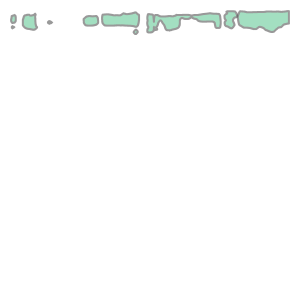

In [10]:
poly = segmentations[0].instances[0].polygon
poly

To make it easier to plot the polygons in the same coordinate system as the images, we created some easy-to-use functions.

`poly_to_mask` converts the polygon to a binary mask in the image's coordinate system, which is easy to plot:

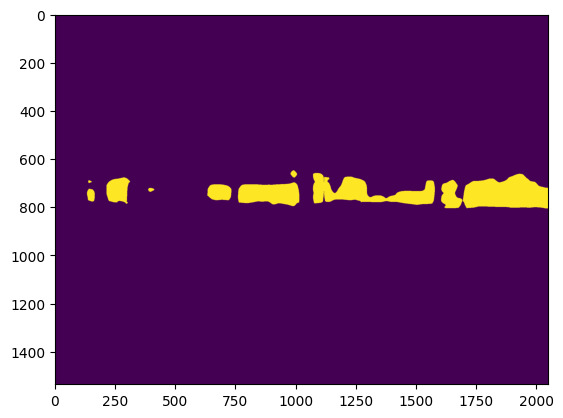

In [11]:
from streetscapes.utils.property_extraction import poly_to_mask, plot_multipolygon
import matplotlib.pyplot as plt

mask = poly_to_mask(poly, image)
plt.imshow(mask)


We can also plot the raw polygon on top of the image with `plot_multipolygon`. This resembles the *streetscapes-explorer* view:

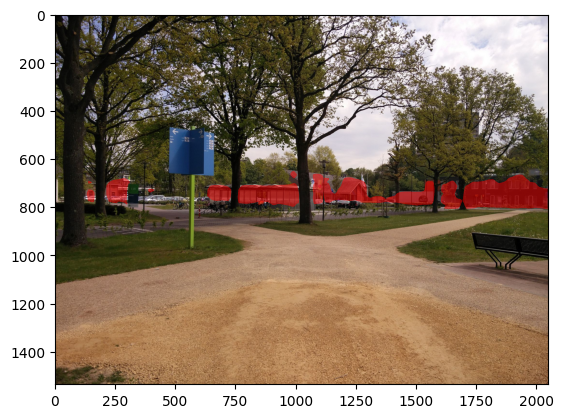

In [12]:
import numpy as np

plt.imshow(np.asarray(image))
plot_multipolygon(poly)

The mask itself is a binary mask, with the same shape as the image:

In [13]:
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1536, 2048))

With the `mask_image` we can mask the original image array, which allows for much easier analysis:

In [14]:
from streetscapes.utils.property_extraction import mask_image

img = mask_image(image, mask)

We can used this masked image to extract the mean red green and blue values from the image data, only for the values covered by the building instance:

In [15]:
r,g,b = img.mean(axis=(0,1)).data
r,g,b  # note: value from 0-255

(np.float64(64.41604773135273),
 np.float64(56.98061353796332),
 np.float64(53.06618501179204))

In this case the building is grey, we can confirm this by displaying the color as a simple rectangle plot:

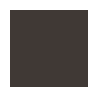

In [16]:
from streetscapes.utils.property_extraction import display_color
display_color((r,g,b))


As a demonstration, we can show the color value of the sign.

We see that the color extracted is indeed blue:

Label: billboard


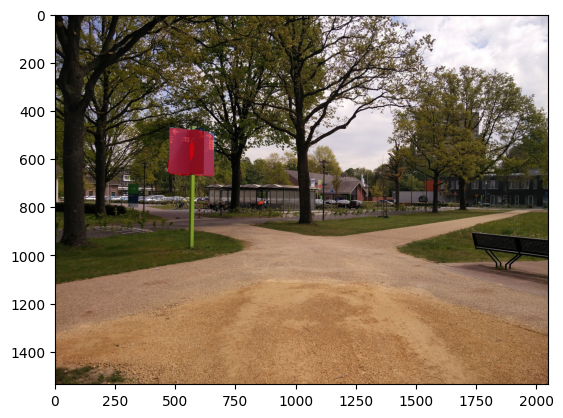

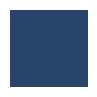

In [17]:
plt.imshow(np.asarray(image))
print("Label:", segmentations[0].instances[8].label)
poly = segmentations[0].instances[8].polygon
plot_multipolygon(poly)

mask = poly_to_mask(poly, image)
img = mask_image(image, mask)
r,g,b = img.mean(axis=(0,1)).data
display_color((r,g,b))


## Example use case: building color

As a last example we can extract building color and plot it on a map.

We first need to define a function that gets the image location. 
Note that this is only implemented for mapillary images here, if you have a different source you need to modify this code.

In [18]:
def get_loc(uuid):
    predicate = db.table("mapillary").image == uuid
    images_filtered = db.table("mapillary").filter(predicate)
    return images_filtered.to_pandas().squeeze()["geometry"]


Now we can loop through all images, select the first building instance and compute the mean Red Green and Blue values:

In [19]:
images = db.table("images").uuid.to_pandas()

result = {}
for uuid in images:
    image = get_image(str(uuid))
    segmentation = get_segmentations(uuid)[0]  # take only the first segmentation run

    for instance in segmentation.instances:
        if instance.label == "building":
            mask = poly_to_mask(instance.polygon, image)
            img = mask_image(image, mask)
            r,g,b = img.mean(axis=(0,1)).data
            break  # advance to next image
    loc = get_loc(uuid)
    result[loc] = (r,g,b)

The result we can plot with matplotlib. It does not look very interesting for this dataset but does demonstrate the functionality.

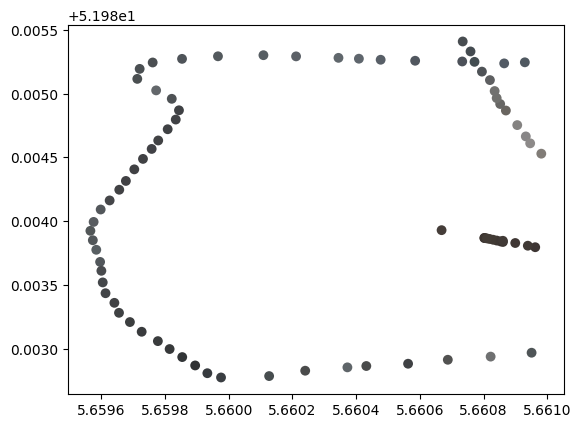

In [20]:
for loc, color in result.items():
    plt.scatter(loc.x, loc.y, s=50, facecolors=tuple([c / 255 for c in color]), edgecolors="none")
